# Классификация SI > median

Это более сложная задача, потому что сам `SI` по данным заметно шумнее и менее линейный.

Основная метрика остаётся `ROC-AUC`, но на `F1` и `Balanced Accuracy` тоже стоит смотреть.

In [10]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from types import SimpleNamespace

import pandas as pd
from IPython.display import Image, display

from src.common.config import RESULTS_DIR, TASKS
from src.common.data import find_dataset_path, load_dataset
from src.common.preprocessing import prepare_task_data
from src.common.training import run_regression_si_task, run_supervised_task

## Настройки запуска

По умолчанию стоит полный режим `nested`. Если нужен быстрый прогон для проверки,
достаточно переключить `EVALUATION_STRATEGY` на `"holdout"`.

In [3]:
TASK_NAME = 'classification_si_gt_median'
EVALUATION_STRATEGY = 'nested'
MODELS = None
SKIP_CATBOOST = False
OUTER_FOLDS = 5
INNER_FOLDS = 3
TEST_SIZE = 0.2
RANDOM_SEED = 42
TOP_K_IMPORTANCE = 20

task = TASKS[TASK_NAME]
dataframe = load_dataset(find_dataset_path())
prepared = prepare_task_data(dataframe, task)

print(f'Задача: {task.title}')
print(f'Матрица признаков: {prepared["X"].shape}')
print(f'Число признаков после фильтрации: {len(prepared["feature_columns"])}')
print(f'Статус проверки на утечку: {prepared["leakage_report"]["status"]}')

Задача: Классификация: SI > 3.846154
Матрица признаков: (1001, 210)
Число признаков после фильтрации: 210
Статус проверки на утечку: passed


## Быстрый срез по таргету

Перед обучением полезно один раз посмотреть, что именно мы подаём в модель.

In [13]:
target_frame = (
    prepared['y']
    .value_counts()
    .sort_index()
    .rename_axis('label')
    .reset_index(name='count')
)
target_frame['share'] = target_frame['count'] / target_frame['count'].sum()
display(target_frame)

,label,count,share
0,0,501,0.5005
1,1,500,0.4995


## Запуск эксперимента

Эта ячейка пересчитывает результаты, пишет артефакты в `results/` и обновляет текстовый отчёт в `reports/`.

In [14]:
args = SimpleNamespace(
    evaluation_strategy=EVALUATION_STRATEGY,
    models=MODELS,
    skip_catboost=SKIP_CATBOOST,
    outer_folds=OUTER_FOLDS,
    inner_folds=INNER_FOLDS,
    test_size=TEST_SIZE,
    random_seed=RANDOM_SEED,
    top_k_importance=TOP_K_IMPORTANCE,
)

summary = run_supervised_task(task, args)
summary

2026-04-20 22:08:30,784 | INFO | Running classification_si_gt_median with models: ['dummy', 'logistic_regression', 'knn', 'svc', 'random_forest', 'extra_trees', 'gradient_boosting', 'catboost']
2026-04-20 22:08:30,785 | INFO | Evaluating model dummy
2026-04-20 22:08:31,277 | INFO | Evaluating model logistic_regression
2026-04-20 22:08:35,943 | INFO | Evaluating model knn
2026-04-20 22:08:42,301 | INFO | Evaluating model svc
2026-04-20 22:09:05,343 | INFO | Evaluating model random_forest
2026-04-20 22:16:25,908 | INFO | Evaluating model extra_trees
2026-04-20 22:19:25,631 | INFO | Evaluating model gradient_boosting
2026-04-20 22:23:02,081 | INFO | Evaluating model catboost
2026-04-20 22:36:38,839 | INFO | Finished classification_si_gt_median. Winner: catboost


{'task_name': 'classification_si_gt_median',
 'title': 'Классификация: SI > 3.846154',
 'problem_type': 'classification',
 'target_column': 'SI',
 'threshold': 3.846154,
 'primary_metric': 'roc_auc',
 'evaluation_strategy': 'nested',
 'random_seed': 42,
 'data_contract_path': '/Users/davidsukhashvili/Desktop/ML/MEPhi/ClassicMl/Neural Networks in Chemistry/results/data_contract.json',
 'leaderboard_path': '/Users/davidsukhashvili/Desktop/ML/MEPhi/ClassicMl/Neural Networks in Chemistry/results/classification_si_gt_median/leaderboard.csv',
 'winner': {'task_name': 'classification_si_gt_median',
  'problem_type': 'classification',
  'target_column': 'SI',
  'primary_metric': 'roc_auc',
  'evaluation_strategy': 'nested',
  'model_name': 'catboost',
  'mode': 'direct',
  'fit_seconds': 816.735225374985,
  'best_params_json': '{"depth": 4, "iterations": 200, "l2_leaf_reg": 1, "learning_rate": 0.03}',
  'roc_auc': 0.7317449504950495,
  'roc_auc_std': 0.019890966480655352,
  'f1': 0.65819845874

## Лидерборд

Сравнение разных моделей.

In [6]:
leaderboard = pd.read_csv(RESULTS_DIR / 'classification_si_gt_median' / 'leaderboard.csv')
display(leaderboard)

,task_name,problem_type,target_column,primary_metric,evaluation_strategy,model_name,mode,fit_seconds,best_params_json,roc_auc,roc_auc_std,f1,f1_std,balanced_accuracy,balanced_accuracy_std
0,classification_si_gt_median,classification,SI,roc_auc,nested,catboost,direct,887.416190,"{""depth"": 4, ""iterations"": 200, ""l2_leaf_reg"":...",0.731745,0.019891,0.658198,0.031937,0.673297,0.016014
1,classification_si_gt_median,classification,SI,roc_auc,nested,extra_trees,direct,199.206131,"{""class_weight"": ""balanced"", ""max_depth"": 8, ""...",0.730651,0.023242,0.652280,0.031780,0.665317,0.023461
2,classification_si_gt_median,classification,SI,roc_auc,nested,random_forest,direct,470.487404,"{""class_weight"": ""balanced"", ""max_depth"": 8, ""...",0.723632,0.019187,0.661059,0.037637,0.672347,0.027049
3,classification_si_gt_median,classification,SI,roc_auc,nested,svc,direct,31.610093,"{""C"": 1.0, ""class_weight"": ""balanced"", ""gamma""...",0.719827,0.022517,0.643424,0.050073,0.654347,0.023927
4,classification_si_gt_median,classification,SI,roc_auc,nested,knn,direct,10.349870,"{""n_neighbors"": 11, ""p"": 2, ""weights"": ""uniform""}",0.716417,0.035986,0.656764,0.042594,0.656337,0.035224
5,classification_si_gt_median,classification,SI,roc_auc,nested,gradient_boosting,direct,243.519849,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",0.712845,0.027280,0.655266,0.030857,0.656297,0.025584
6,classification_si_gt_median,classification,SI,roc_auc,nested,logistic_regression,direct,7.863409,"{""C"": 0.1, ""class_weight"": ""balanced""}",0.686065,0.022421,0.623425,0.024766,0.625356,0.020696
7,classification_si_gt_median,classification,SI,roc_auc,nested,dummy,direct,0.840200,"{""strategy"": ""stratified""}",0.506416,0.010512,0.195608,0.239570,0.491574,0.012468


## Короткий разбор результата

In [7]:
winner = leaderboard.iloc[0]
baseline_rows = leaderboard[leaderboard['model_name'] == 'dummy']
baseline = baseline_rows.iloc[0] if not baseline_rows.empty else None

print(
    f"Победитель: {winner['model_name']} "
    f"({winner['mode']}), "
    f"основная метрика {winner['primary_metric']} = {winner[winner['primary_metric']]:.6f}."
)
if baseline is not None:
    print(
        f"Для сравнения dummy даёт {baseline[baseline['primary_metric']]:.6f} по той же метрике."
    )
print(f"Лучшие параметры: {winner['best_params_json']}")

Победитель: catboost (direct), основная метрика roc_auc = 0.731745.
Для сравнения dummy даёт 0.506416 по той же метрике.
Лучшие параметры: {"depth": 4, "iterations": 200, "l2_leaf_reg": 1, "learning_rate": 0.03}


## Что видно по важности признаков

In [15]:
importance_path = RESULTS_DIR / 'classification_si_gt_median' / 'winner_feature_importance.csv'
if importance_path.exists():
    display(pd.read_csv(importance_path).head(15))

,feature,importance,abs_importance
0,BCUT2D_MRLOW,3.634035,3.634035
1,NHOHCount,3.558555,3.558555
2,BCUT2D_CHGLO,2.626942,2.626942
3,VSA_EState4,2.357894,2.357894
4,NumSaturatedCarbocycles,2.312444,2.312444
5,SMR_VSA4,2.266209,2.266209
6,BCUT2D_MWLOW,2.142539,2.142539
7,FractionCSP3,2.114737,2.114737
8,SMR_VSA7,1.990846,1.990846
9,NumSaturatedHeterocycles,1.825847,1.825847


## Матрица ошибок

Для бинарных задач полезно смотреть не только на метрики, но и на тип ошибок.

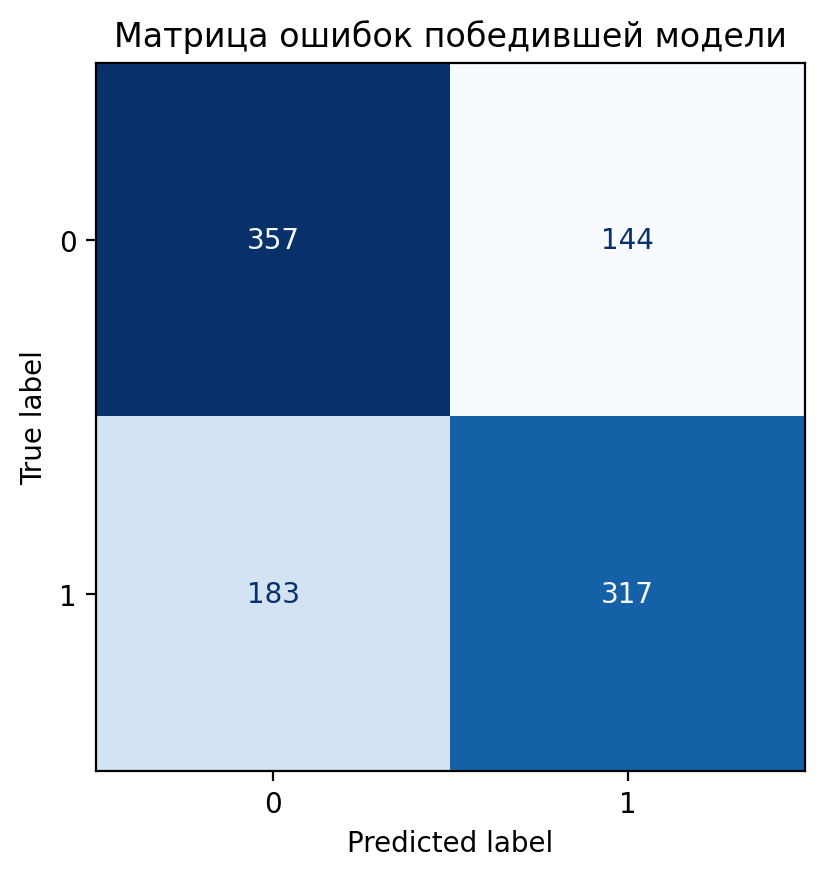

In [16]:
confusion_path = RESULTS_DIR / 'classification_si_gt_median' / 'winner_confusion_matrix.png'
if confusion_path.exists():
    display(Image(filename=str(confusion_path)))

## Итог
TODO: написать почему именно эта модель победила и порассуждать почему в этой задаче именно она показывает хороший результат